# Papaloizou-Pringle Disk Profiles Calculation

**Physical Model:**
- Pressure/Density: $\frac{\tilde{p}}{\tilde{\rho}} = \frac{1}{n+1}\left(\frac{1}{\tilde{r}} - \frac{1}{2\tilde{r}^2} - C'\right)$
- Density: $\tilde{\rho} = \left[\frac{\tilde{p}/\tilde{\rho}}{(\tilde{p}/\tilde{\rho})_{\text{center}}}\right]^n$
- Azimuthal velocity: $\tilde{v}_\phi = \frac{1}{\tilde{r}}$ (constant specific angular momentum)
- Disk boundaries: Solutions for $\frac{1}{\tilde{r}} - \frac{1}{2\tilde{r}^2} - C' = 0$

**Parameters:**
- γ (adiabatic index)
- C' (disk width parameter)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Physical parameters
gamma = 1.3  # 5.0/3.0      # Adiabatic index
n = 1.0/(gamma - 1.0)  # Polytropic index

print("="*60)
print("PAPALOIZOU-PRINGLE DISK MODEL")
print("="*60)
print(f"Adiabatic index:  γ = {gamma:.6f}")
print(f"Polytropic index: n = {n:.6f}")
print(f"")
print(f"Valid range for C': 0 < C' < 0.5")
print(f"  (ensures real disk boundaries)")
print("="*60)

PAPALOIZOU-PRINGLE DISK MODEL
Adiabatic index:  γ = 1.300000
Polytropic index: n = 3.333333

Valid range for C': 0 < C' < 0.5
  (ensures real disk boundaries)


In [3]:
def disk_function(r_tilde, C_prime):
    """
    Disk function f(r̃) = 1/r̃ - 1/(2r̃²) - C'
    Disk exists where f > 0
    """
    return 1.0/r_tilde - 1.0/(2.0*r_tilde**2) - C_prime

def calculate_boundaries(C_prime):
    """
    Calculate inner and outer disk boundaries
    Solutions of: r̃² - r̃/C' + 1/(2C') = 0
    """
    if C_prime <= 0 or C_prime >= 0.5:
        return None, None
    
    discriminant = 1.0 - 2.0*C_prime
    if discriminant < 0:
        return None, None
    
    r_inner = (1.0 - np.sqrt(discriminant)) / (2.0 * C_prime)
    r_outer = (1.0 + np.sqrt(discriminant)) / (2.0 * C_prime)
    
    return r_inner, r_outer

def pressure_over_density(r_tilde, C_prime):
    """
    Calculate p̃/ρ̃ = f(r̃)/(n+1)
    Returns 0 outside disk boundaries
    """
    f = disk_function(r_tilde, C_prime)
    p_over_rho = np.where(f > 0, f / (n + 1.0), 0.0)
    return p_over_rho

def density_profile(r_tilde, C_prime):
    """
    Calculate density profile ρ̃(r̃)
    Normalized to ρ̃ = 1 at disk center (r̃ = 1)
    """
    p_over_rho = pressure_over_density(r_tilde, C_prime)
    p_over_rho_center = pressure_over_density(1.0, C_prime)
    
    if p_over_rho_center <= 0:
        return np.zeros_like(r_tilde)
    
    # ρ̃ = [(p̃/ρ̃) / (p̃/ρ̃)_center]^n
    ratio = p_over_rho / p_over_rho_center
    rho = np.where(ratio > 0, ratio**n, 0.0)
    
    return rho

def pressure_profile(r_tilde, C_prime):
    """
    Calculate pressure profile p̃(r̃)
    p̃ = ρ̃ × (p̃/ρ̃)
    """
    rho = density_profile(r_tilde, C_prime)
    p_over_rho = pressure_over_density(r_tilde, C_prime)
    return rho * p_over_rho

def azimuthal_velocity(r_tilde):
    """
    Azimuthal velocity with constant specific angular momentum: ṽ_φ = 1/r̃
    For Papaloizou-Pringle disk: l₀ = r×v_φ = const → v_φ = l₀/r
    """
    return 1.0 / r_tilde

In [4]:
def plot_disk_profiles(C_prime=0.43):
    """
    Plot density, pressure, and velocity profiles for given C'
    """
    # Calculate boundaries
    r_inner, r_outer = calculate_boundaries(C_prime)
    
    if r_inner is None or r_outer is None:
        print(f"ERROR: Invalid C' = {C_prime:.3f}")
        print(f"Must satisfy: 0 < C' < 0.5")
        return
    
    # Create radial grid
    r_tilde = np.linspace(0.3, 10.0, 1000)
    
    # Calculate profiles
    rho = density_profile(r_tilde, C_prime)
    press = pressure_profile(r_tilde, C_prime)
    v_phi = azimuthal_velocity(r_tilde)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 8)) # 14, 10
    fig.suptitle(f"Papaloizou-Pringle Disk: C' = {C_prime:.3f}", fontsize=16, fontweight='bold')
    
    # Plot 1: Density
    ax1 = axes[0]
    ax1.plot(r_tilde, rho, 'b-', linewidth=2.5, label=r'$\tilde{\rho}(\tilde{r})$')
    ax1.axvline(r_inner, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Inner: r̃ = {r_inner:.3f}')
    ax1.axvline(r_outer, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Outer: r̃ = {r_outer:.3f}')
    ax1.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Center: r̃ = 1')
    ax1.fill_between(r_tilde, 0, rho, where=(r_tilde >= r_inner) & (r_tilde <= r_outer), 
                     alpha=0.2, color='blue', label='Disk region')
    ax1.set_xlabel(r'$\tilde{r}$', fontsize=12)
    ax1.set_ylabel(r'$\tilde{\rho}$', fontsize=12)
    ax1.set_title('Density Profile', fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.set_xlim(0.3, 10.0)
    ax1.set_ylim(0, max(rho)*1.1 if max(rho) > 0 else 1.0)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Pressure
    ax2 = axes[1]
    ax2.plot(r_tilde, press, 'r-', linewidth=2.5, label=r'$\tilde{p}(\tilde{r})$')
    ax2.axvline(r_inner, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.axvline(r_outer, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.fill_between(r_tilde, 0, press, where=(r_tilde >= r_inner) & (r_tilde <= r_outer), 
                     alpha=0.2, color='red', label='Disk region')
    ax2.set_xlabel(r'$\tilde{r}$', fontsize=12)
    ax2.set_ylabel(r'$\tilde{p}$', fontsize=12)
    ax2.set_title('Pressure Profile', fontsize=13, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.set_xlim(0.3, 10.0)
    ax2.set_ylim(0, max(press)*1.1 if max(press) > 0 else 1.0)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Azimuthal Velocity
    ax3 = axes[2]
    ax3.plot(r_tilde, v_phi, 'g-', linewidth=2.5, label=r'$\tilde{v}_\phi(\tilde{r}) = 1/\tilde{r}$')
    ax3.axvline(r_inner, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax3.axvline(r_outer, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax3.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax3.fill_between(r_tilde, 0, v_phi, where=(r_tilde >= r_inner) & (r_tilde <= r_outer), 
                     alpha=0.2, color='green', label='Disk region')
    ax3.set_xlabel(r'$\tilde{r}$', fontsize=12)
    ax3.set_ylabel(r'$\tilde{v}_\phi$', fontsize=12)
    ax3.set_title('Azimuthal Velocity (Constant Angular Momentum)', fontsize=13, fontweight='bold')
    ax3.legend(loc='best', fontsize=10)
    ax3.set_xlim(0.3, 10.0)
    ax3.set_ylim(0, max(v_phi)*1.1 if max(v_phi) > 0 else 1.0)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("="*70)
    print(f"DISK PARAMETERS FOR C' = {C_prime:.4f}")
    print("="*70)
    print(f"Inner boundary:  r̃_in  = {r_inner:.9f}")
    print(f"Outer boundary:  r̃_out = {r_outer:.9f}")
    print(f"Disk width:      Δr̃    = {r_outer - r_inner:.6f}")
    print(f"Width ratio:     r_out/r_in = {r_outer/r_inner:.4f}")
    print(f"")
    print(f"At disk center (r̃ = 1):")
    print(f"  Density:              ρ̃     = {density_profile(1.0, C_prime):.6f}")
    print(f"  Pressure:             p̃     = {pressure_profile(1.0, C_prime):.6f}")
    print(f"  Azimuthal velocity:   ṽ_φ   = {azimuthal_velocity(1.0):.6f}")
    print(f"  Pressure/Density:     p̃/ρ̃   = {pressure_over_density(1.0, C_prime):.6f}")
    print("="*70)

## Interactive Plot

Adjust **C'** to see how the disk structure changes:

In [5]:
# Interactive widget
interact(plot_disk_profiles, 
         C_prime=FloatSlider(value=0.43, min=0.05, max=0.5, step=0.01, 
                            description="C':", continuous_update=False,
                            style={'description_width': '50px'},
                            layout={'width': '600px'}));

interactive(children=(FloatSlider(value=0.43, continuous_update=False, description="C':", layout=Layout(width=…

## Examples of Different Disk Widths

Compare several values:

In [6]:
# Compare different C' values
C_prime_values = [0.1, 0.2, 0.3, 0.43, 0.45]

print("="*80)
print("COMPARISON OF DISK STRUCTURES")
print("="*80)
header = f"{'C prime':<10} {'r_in':<12} {'r_out':<12} {'Delta_r':<12} {'r_out/r_in':<12}"
print(header)
print("-"*80)

for C_p in C_prime_values:
    r_in, r_out = calculate_boundaries(C_p)
    if r_in is not None:
        delta_r = r_out - r_in
        ratio = r_out / r_in
        print(f"{C_p:<10.2f} {r_in:<12.6f} {r_out:<12.6f} {delta_r:<12.6f} {ratio:<12.4f}")

print("="*80)

COMPARISON OF DISK STRUCTURES
C prime    r_in         r_out        Delta_r      r_out/r_in  
--------------------------------------------------------------------------------
0.10       0.527864     9.472136     8.944272     17.9443     
0.20       0.563508     4.436492     3.872983     7.8730      
0.30       0.612574     2.720759     2.108185     4.4415      
0.43       0.727714     1.597867     0.870153     2.1957      
0.45       0.759747     1.462475     0.702728     1.9250      


## Manual Calculating

Plot specific values by calling the function directly:

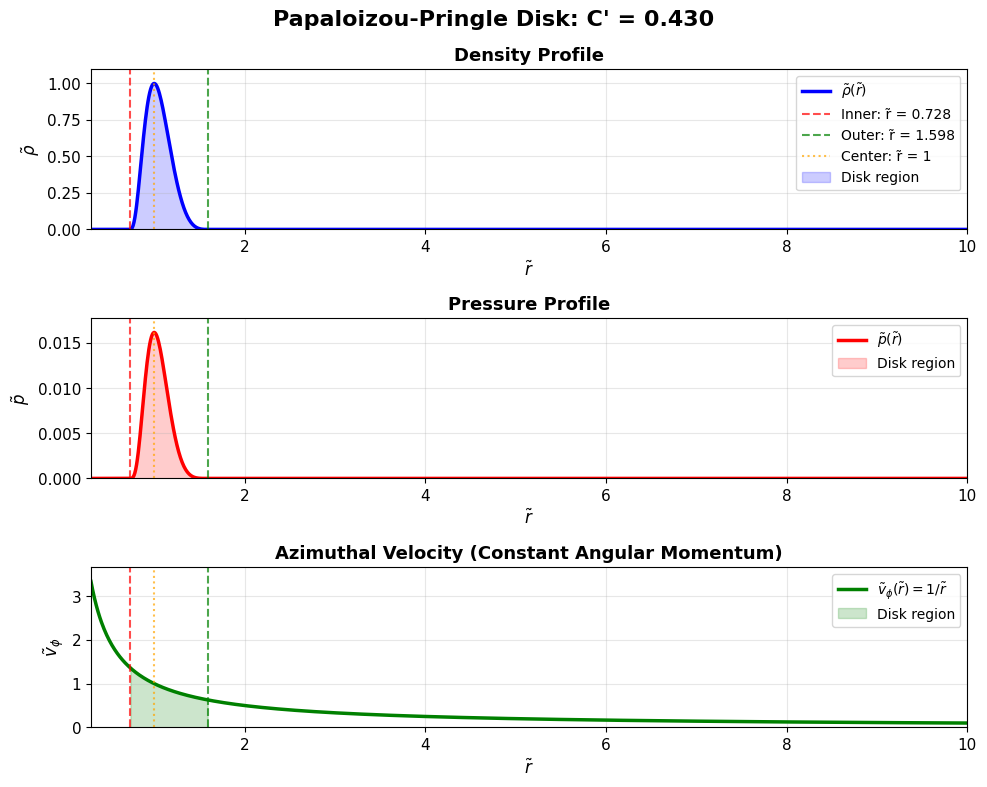

DISK PARAMETERS FOR C' = 0.4300
Inner boundary:  r̃_in  = 0.727714257
Outer boundary:  r̃_out = 1.597867138
Disk width:      Δr̃    = 0.870153
Width ratio:     r_out/r_in = 2.1957

At disk center (r̃ = 1):
  Density:              ρ̃     = 1.000000
  Pressure:             p̃     = 0.016154
  Azimuthal velocity:   ṽ_φ   = 1.000000
  Pressure/Density:     p̃/ρ̃   = 0.016154


In [7]:
# Example: Plot for C' = 0.43 (NGC 1068 value)
plot_disk_profiles(C_prime=0.43)

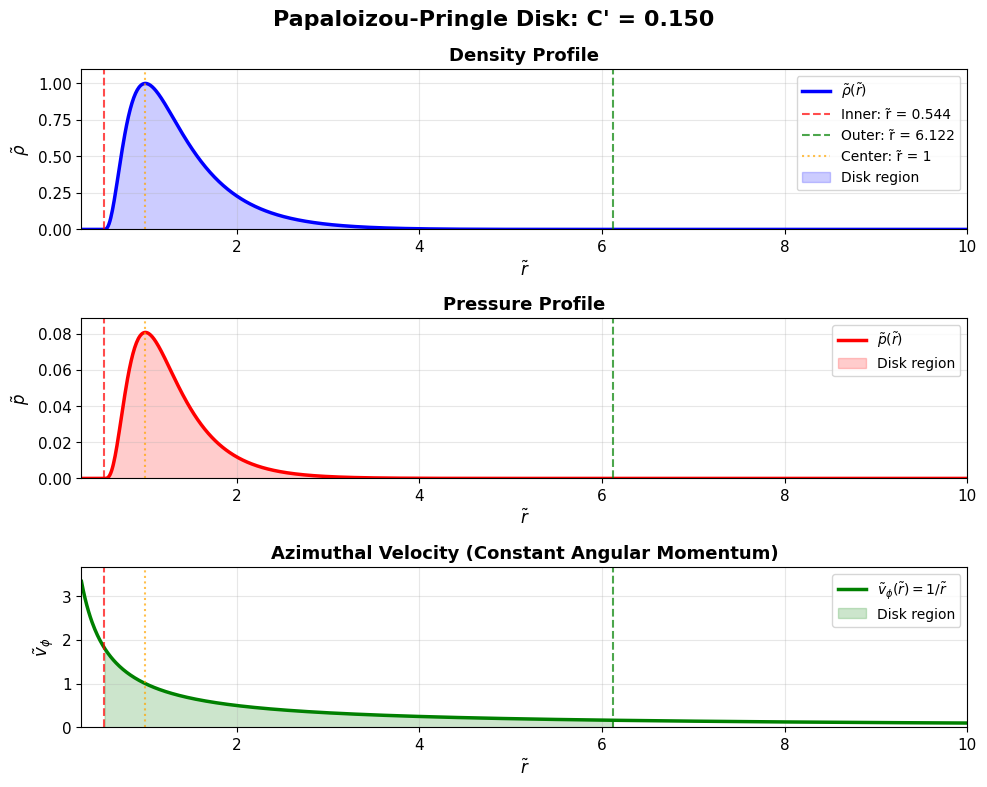

DISK PARAMETERS FOR C' = 0.1500
Inner boundary:  r̃_in  = 0.544466578
Outer boundary:  r̃_out = 6.122200088
Disk width:      Δr̃    = 5.577734
Width ratio:     r_out/r_in = 11.2444

At disk center (r̃ = 1):
  Density:              ρ̃     = 1.000000
  Pressure:             p̃     = 0.080769
  Azimuthal velocity:   ṽ_φ   = 1.000000
  Pressure/Density:     p̃/ρ̃   = 0.080769


In [8]:
# Example: Very wide disk
plot_disk_profiles(C_prime=0.15)

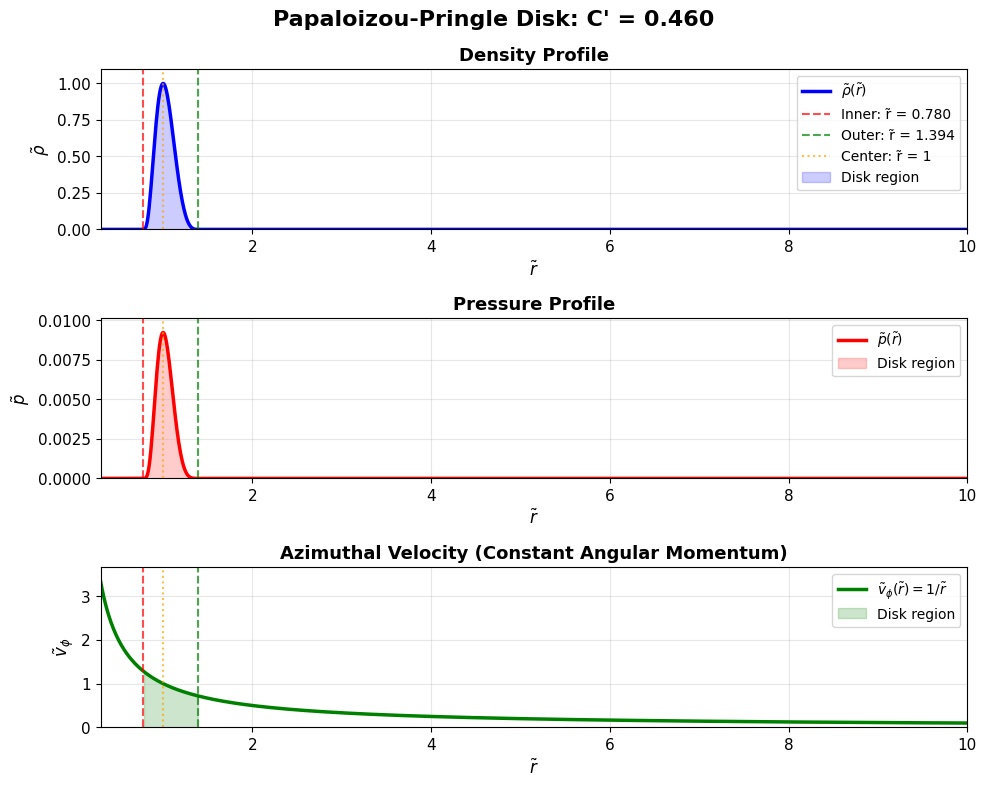

DISK PARAMETERS FOR C' = 0.4600
Inner boundary:  r̃_in  = 0.779518791
Outer boundary:  r̃_out = 1.394394253
Disk width:      Δr̃    = 0.614875
Width ratio:     r_out/r_in = 1.7888

At disk center (r̃ = 1):
  Density:              ρ̃     = 1.000000
  Pressure:             p̃     = 0.009231
  Azimuthal velocity:   ṽ_φ   = 1.000000
  Pressure/Density:     p̃/ρ̃   = 0.009231


In [9]:
# Example: Very narrow disk
plot_disk_profiles(C_prime=0.46)

## Disk Profiles with Floors (dfloor / pfloor)

Density and pressure profiles computed with minimum floor values:
- **dfloor** — minimum density floor (applied outside disk or where ρ < dfloor)
- **pfloor** — minimum pressure floor (applied where p < pfloor)

Solid line — effective profile (floors applied).  
Dashed line — theoretical profile (no floors).  
Horizontal dotted line — floor level.  
Vertical dashed lines — disk boundaries (where theoretical profile = 0).  
Shaded region — area where theoretical value is **below** the floor.

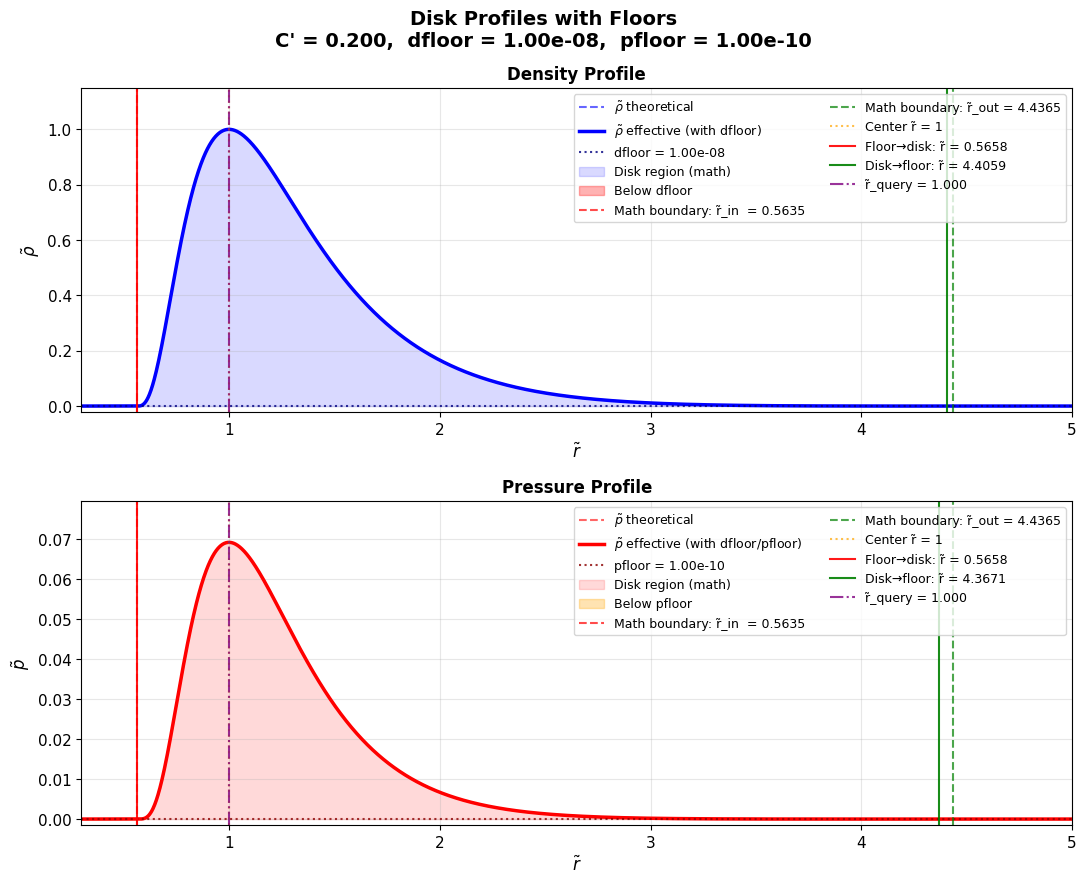

DISK BOUNDARIES  (C' = 0.2000)
  Mathematical boundaries (disk function = 0):
    r̃_in  = 0.563508327
    r̃_out = 4.436491673
    Width  = 3.872983,   r_out/r_in = 7.8730

  Floor-clipped boundaries (floor→disk transitions):
    Density  (dfloor=1.00e-08):  r̃ = 0.565833  →  r̃ = 4.405861   (width = 3.840028)
    Pressure (pfloor=1.00e-10):  r̃ = 0.565833  →  r̃ = 4.367053   (width = 3.801220)

VALUES AT  r̃ = 1.0000
  Inside disk  (r̃_in=0.5635, r̃_out=4.4365)
  Theoretical density:       ρ̃_th    = 1.000000e+00
  Effective density:         ρ̃_eff   = 1.000000e+00  
  Theoretical pressure:      p̃_th    = 6.923077e-02
  Effective pressure:        p̃_eff   = 6.923077e-02  
  Azimuthal velocity:        ṽ_φ     = 1.000000
  p̃/ρ̃ (theoretical):        6.923077e-02


In [10]:
# ─── Parameters (edit these) ─────────────────────────────────────────────────
C_PRIME = 0.2    # disk width parameter C'
DFLOOR  = 1e-8   # minimum density floor
PFLOOR  = 1e-10  # minimum pressure floor
R_QUERY = 1.0    # radial point at which to evaluate ρ and p (in units of r̃)
# ─────────────────────────────────────────────────────────────────────────────

def density_floored(r_tilde, C_prime, dfloor):
    """Density profile with lower floor dfloor applied."""
    rho = density_profile(r_tilde, C_prime)
    return np.maximum(rho, dfloor)

def pressure_floored(r_tilde, C_prime, dfloor, pfloor):
    """Pressure profile with density floor dfloor and pressure floor pfloor."""
    rho_f      = density_floored(r_tilde, C_prime, dfloor)
    p_over_rho = pressure_over_density(r_tilde, C_prime)
    return np.maximum(rho_f * p_over_rho, pfloor)

def _floor_effective_bounds(profile_th, floor_val, r_tilde, r_inner, r_outer):
    """
    Find effective (floor-clipped) inner and outer boundaries:
    the radii inside the disk where the theoretical profile first/last
    rises above the floor value (i.e., floor→disk and disk→floor transitions).
    Returns (r_eff_in, r_eff_out), or (None, None) if profile never exceeds floor.
    """
    in_disk      = (r_tilde >= r_inner) & (r_tilde <= r_outer)
    above_floor  = (profile_th >= floor_val) & in_disk
    if above_floor.any():
        return float(r_tilde[above_floor][0]), float(r_tilde[above_floor][-1])
    return None, None

def plot_floored_profiles(C_prime=C_PRIME, dfloor=DFLOOR, pfloor=PFLOOR, r_query=R_QUERY):
    """
    Plot density and pressure profiles with dfloor/pfloor applied.
    Shows mathematical disk boundaries and floor-clipped effective boundaries.
    Prints both boundary sets and evaluates profiles at r_query.
    """
    r_inner, r_outer = calculate_boundaries(C_prime)
    if r_inner is None or r_outer is None:
        print(f"Error: invalid C' = {C_prime:.3f}. Must satisfy 0 < C' < 0.5")
        return

    r_tilde = np.linspace(0.3, 10.0, 5000)

    # Theoretical profiles (no floors)
    rho_th   = density_profile(r_tilde, C_prime)
    press_th = pressure_profile(r_tilde, C_prime)

    # Effective profiles (with floors)
    rho_eff   = density_floored(r_tilde, C_prime, dfloor)
    press_eff = pressure_floored(r_tilde, C_prime, dfloor, pfloor)

    # Masks: where theoretical value is below the floor
    rho_below_floor   = rho_th   < dfloor
    press_below_floor = press_th < pfloor

    # Effective (floor-clipped) boundaries
    r_eff_in_rho,   r_eff_out_rho   = _floor_effective_bounds(rho_th,   dfloor, r_tilde, r_inner, r_outer)
    r_eff_in_press, r_eff_out_press = _floor_effective_bounds(press_th, pfloor, r_tilde, r_inner, r_outer)

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9))
    fig.suptitle(
        f"Disk Profiles with Floors\n"
        f"C' = {C_prime:.3f},  dfloor = {dfloor:.2e},  pfloor = {pfloor:.2e}",
        fontsize=14, fontweight='bold'
    )

    def _add_boundaries(ax, r_eff_in, r_eff_out, r_q):
        # Mathematical disk boundaries
        ax.axvline(r_inner, color='red',   linestyle='--', lw=1.5, alpha=0.7,
                   label=f'Math boundary: r̃_in  = {r_inner:.4f}')
        ax.axvline(r_outer, color='green', linestyle='--', lw=1.5, alpha=0.7,
                   label=f'Math boundary: r̃_out = {r_outer:.4f}')
        ax.axvline(1.0,     color='orange', linestyle=':', lw=1.5, alpha=0.7,
                   label='Center r̃ = 1')
        # Effective (floor-clipped) boundaries
        if r_eff_in is not None:
            ax.axvline(r_eff_in,  color='red',   linestyle='-', lw=1.5, alpha=0.9,
                       label=f'Floor→disk: r̃ = {r_eff_in:.4f}')
            ax.axvline(r_eff_out, color='green', linestyle='-', lw=1.5, alpha=0.9,
                       label=f'Disk→floor: r̃ = {r_eff_out:.4f}')
        # Query point
        if 0.3 <= r_q <= 10.0:
            ax.axvline(r_q, color='purple', linestyle='-.', lw=1.5, alpha=0.8,
                       label=f'r̃_query = {r_q:.3f}')

    # ── Subplot 1: Density ────────────────────────────────────────────────────
    ax1.plot(r_tilde, rho_th,  'b--', lw=1.5, alpha=0.6,
             label=r'$\tilde{\rho}$ theoretical')
    ax1.plot(r_tilde, rho_eff, 'b-',  lw=2.5,
             label=r'$\tilde{\rho}$ effective (with dfloor)')
    ax1.axhline(dfloor, color='navy', linestyle=':', lw=1.5, alpha=0.8,
                label=f'dfloor = {dfloor:.2e}')
    ax1.fill_between(r_tilde, 0, rho_eff,
                     where=(r_tilde >= r_inner) & (r_tilde <= r_outer),
                     alpha=0.15, color='blue', label='Disk region (math)')
    ax1.fill_between(r_tilde, 0, rho_eff,
                     where=rho_below_floor,
                     alpha=0.30, color='red', label='Below dfloor')
    _add_boundaries(ax1, r_eff_in_rho, r_eff_out_rho, r_query)
    ax1.set_xlabel(r'$\tilde{r}$', fontsize=12)
    ax1.set_ylabel(r'$\tilde{\rho}$', fontsize=12)
    ax1.set_title('Density Profile', fontsize=12, fontweight='bold')
    ax1.set_xlim(0.3, 5.0)
    top_rho = float(np.max(rho_eff)) * 1.15
    ax1.set_ylim(-top_rho * 0.02, top_rho if top_rho > 0 else 1.0)
    ax1.legend(loc='upper right', fontsize=9, ncol=2)
    ax1.grid(True, alpha=0.3)

    # ── Subplot 2: Pressure ───────────────────────────────────────────────────
    ax2.plot(r_tilde, press_th,  'r--', lw=1.5, alpha=0.6,
             label=r'$\tilde{p}$ theoretical')
    ax2.plot(r_tilde, press_eff, 'r-',  lw=2.5,
             label=r'$\tilde{p}$ effective (with dfloor/pfloor)')
    ax2.axhline(pfloor, color='darkred', linestyle=':', lw=1.5, alpha=0.8,
                label=f'pfloor = {pfloor:.2e}')
    ax2.fill_between(r_tilde, 0, press_eff,
                     where=(r_tilde >= r_inner) & (r_tilde <= r_outer),
                     alpha=0.15, color='red', label='Disk region (math)')
    ax2.fill_between(r_tilde, 0, press_eff,
                     where=press_below_floor,
                     alpha=0.30, color='orange', label='Below pfloor')
    _add_boundaries(ax2, r_eff_in_press, r_eff_out_press, r_query)
    ax2.set_xlabel(r'$\tilde{r}$', fontsize=12)
    ax2.set_ylabel(r'$\tilde{p}$', fontsize=12)
    ax2.set_title('Pressure Profile', fontsize=12, fontweight='bold')
    ax2.set_xlim(0.3, 5.0)
    top_p = float(np.max(press_eff)) * 1.15
    ax2.set_ylim(-top_p * 0.02, top_p if top_p > 0 else 1.0)
    ax2.legend(loc='upper right', fontsize=9, ncol=2)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Boundary summary ──────────────────────────────────────────────────────
    print("=" * 65)
    print(f"DISK BOUNDARIES  (C' = {C_prime:.4f})")
    print("=" * 65)
    print(f"  Mathematical boundaries (disk function = 0):")
    print(f"    r̃_in  = {r_inner:.9f}")
    print(f"    r̃_out = {r_outer:.9f}")
    print(f"    Width  = {r_outer - r_inner:.6f},   r_out/r_in = {r_outer / r_inner:.4f}")

    print(f"\n  Floor-clipped boundaries (floor→disk transitions):")
    if r_eff_in_rho is not None:
        print(f"    Density  (dfloor={dfloor:.2e}):  r̃ = {r_eff_in_rho:.6f}  →  r̃ = {r_eff_out_rho:.6f}   (width = {r_eff_out_rho - r_eff_in_rho:.6f})")
    else:
        print(f"    Density  (dfloor={dfloor:.2e}):  entire disk below floor")

    if r_eff_in_press is not None:
        print(f"    Pressure (pfloor={pfloor:.2e}):  r̃ = {r_eff_in_press:.6f}  →  r̃ = {r_eff_out_press:.6f}   (width = {r_eff_out_press - r_eff_in_press:.6f})")
    else:
        print(f"    Pressure (pfloor={pfloor:.2e}):  entire disk below floor")

    # ── Values at r_query ─────────────────────────────────────────────────────
    print()
    print("=" * 65)
    print(f"VALUES AT  r̃ = {r_query:.4f}")
    print("=" * 65)
    r_q = np.array([r_query])

    rho_q_th     = float(density_profile(r_q, C_prime))
    rho_q_eff    = float(density_floored(r_q, C_prime, dfloor))
    p_q_th       = float(pressure_profile(r_q, C_prime))
    p_q_eff      = float(pressure_floored(r_q, C_prime, dfloor, pfloor))
    v_phi_q      = float(azimuthal_velocity(r_q))
    p_over_rho_q = float(pressure_over_density(r_q, C_prime))

    location = "Inside disk" if r_inner <= r_query <= r_outer else "Outside disk"
    print(f"  {location}  (r̃_in={r_inner:.4f}, r̃_out={r_outer:.4f})")
    print(f"  Theoretical density:       ρ̃_th    = {rho_q_th:.6e}")
    print(f"  Effective density:         ρ̃_eff   = {rho_q_eff:.6e}  {'← dfloor' if rho_q_eff == dfloor else ''}")
    print(f"  Theoretical pressure:      p̃_th    = {p_q_th:.6e}")
    print(f"  Effective pressure:        p̃_eff   = {p_q_eff:.6e}  {'← pfloor' if p_q_eff == pfloor else ''}")
    print(f"  Azimuthal velocity:        ṽ_φ     = {v_phi_q:.6f}")
    print(f"  p̃/ρ̃ (theoretical):        {p_over_rho_q:.6e}")
    print("=" * 65)

# ── Run ───────────────────────────────────────────────────────────────────────
plot_floored_profiles(C_prime=C_PRIME, dfloor=DFLOOR, pfloor=PFLOOR, r_query=R_QUERY)

### Interactive Mode with Floors

Adjust **C'**, **dfloor**, **pfloor**, and the query point **r̃** with the sliders:

In [ ]:
from ipywidgets import FloatLogSlider

interact(
    plot_floored_profiles,
    C_prime=FloatSlider(value=0.43, min=0.05, max=0.49, step=0.01,
                        description="C':", continuous_update=False,
                        style={'description_width': '80px'}, layout={'width': '550px'}),
    dfloor=FloatLogSlider(value=1e-4, base=10, min=-8, max=-1, step=0.5,
                          description='dfloor:', continuous_update=False,
                          style={'description_width': '80px'}, layout={'width': '550px'}),
    pfloor=FloatLogSlider(value=1e-6, base=10, min=-10, max=-1, step=0.5,
                          description='pfloor:', continuous_update=False,
                          style={'description_width': '80px'}, layout={'width': '550px'}),
    r_query=FloatSlider(value=1.5, min=0.3, max=10.0, step=0.1,
                        description='r̃ query:', continuous_update=False,
                        style={'description_width': '80px'}, layout={'width': '550px'}),
);

interactive(children=(FloatSlider(value=0.43, continuous_update=False, description="C':", layout=Layout(width=…